In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
df=pd.read_csv("customer_churn_prediction_dataset.csv")

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.index

RangeIndex(start=0, stop=300, step=1)

In [6]:
df.isnull()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
296,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
297,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
298,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df.isnull().values.any()

np.False_

In [9]:
df.drop(['customerID'],axis=1,inplace=True)

In [10]:
X=df.drop(['Churn'],axis=1)

In [11]:
y=df['Churn']

In [12]:
df['TotalCharges'].value_counts() #If blanks exist, clean them:

,count
TotalCharges,
2154.80,2
1051.68,1
3478.28,1
3983.25,1
1244.03,1
...,...
171.85,1
3502.84,1
2807.55,1


In [13]:
df['TotalCharges']=df['TotalCharges'].replace(" ",None)

In [14]:
df['TotalCharges'].dtype

dtype('float64')

# convert target value into numeric value

In [15]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)

In [16]:
print(y)

[1 1 1 0 1 0 1 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1 1 0 1 0 1 1 0 1 1 1 0 1 1 0 1
 1 1 1 1 0 0 1 1 1 0 0 1 1 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 1 0 0 0 1 0 1 0
 1 1 0 1 1 0 0 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 0 1 0 1 1 0 0 0 0 0 1 1 1
 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1 1 0 0 0 0 0 1 0 0 0 1
 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1
 1 1 1 0 1 1 1 0 0 0 0 1 1 1 0 1 1 0 0 0 1 1 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0
 0 1 1 0 1 1 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0 1 0 0 0 1
 0 0 0 1 0 1 0 1 0 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 1 1 0
 1 1 0 1]


In [17]:
print(le.classes_)

['No' 'Yes']


In [18]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,5,No,Yes,No,No,Yes,No,No,No,No internet service,Month-to-month,Yes,Credit card,27.43,137.15,Yes
1,Female,0,No,No,42,Yes,No phone service,DSL,Yes,Yes,No,No,No internet service,No internet service,Two year,No,Electronic check,38.28,1607.76,Yes
2,Male,0,No,No,61,Yes,No phone service,No,No,Yes,No,Yes,Yes,No,One year,No,Bank transfer,106.44,6492.84,Yes
3,Male,1,No,Yes,22,Yes,No,No,No internet service,No internet service,Yes,No,No internet service,Yes,Month-to-month,No,Electronic check,92.49,2034.78,No
4,Male,1,Yes,Yes,21,No,No,DSL,No,No,No internet service,No,No,No internet service,One year,No,Bank transfer,19.63,412.23,Yes


now convert independent variable into numeric data set

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            300 non-null    object 
 1   SeniorCitizen     300 non-null    int64  
 2   Partner           300 non-null    object 
 3   Dependents        300 non-null    object 
 4   tenure            300 non-null    int64  
 5   PhoneService      300 non-null    object 
 6   MultipleLines     300 non-null    object 
 7   InternetService   300 non-null    object 
 8   OnlineSecurity    300 non-null    object 
 9   OnlineBackup      300 non-null    object 
 10  DeviceProtection  300 non-null    object 
 11  TechSupport       300 non-null    object 
 12  StreamingTV       300 non-null    object 
 13  StreamingMovies   300 non-null    object 
 14  Contract          300 non-null    object 
 15  PaperlessBilling  300 non-null    object 
 16  PaymentMethod     300 non-null    object 
 1

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct=ColumnTransformer(transformers=[('encoder',OneHotEncoder(),['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod'])],remainder='passthrough')
X=ct.fit_transform(X)

In [21]:
print(X[:18])

[[0.00000e+00 1.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 1.00000e+00
  1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00
  0.00000e+00 1.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 1.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00
  0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  1.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  1.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  5.00000e+00 2.74300e+01 1.37150e+02]
 [1.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00
  0.00000e+00 1.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 1.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00
  0.00000e+00 1.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00
  1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 1.00000e+00

# Now check weather dataset or balance or imbalance

In [22]:
df['Churn'].value_counts()

,count
Churn,
No,161
Yes,139


In [23]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,53.666667
Yes,46.333333


<Axes: xlabel='Churn', ylabel='count'>

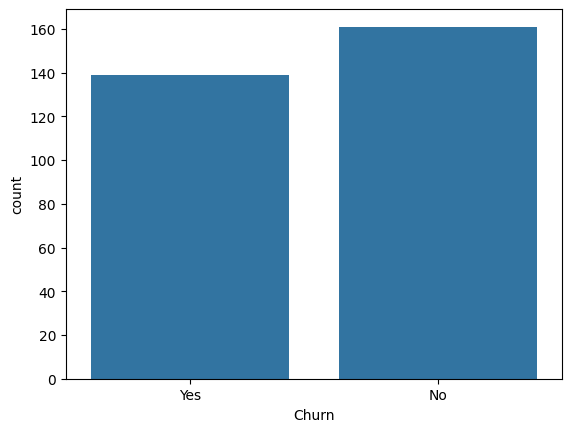

In [24]:
import seaborn as sns
sns.countplot(x='Churn',data=df)

# Balance imbalance dataset

In [25]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

#split first

In [26]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Apply SMOTE only on training data

In [27]:
smote=SMOTE(random_state=42)
X_train_sm,y_train_sm=smote.fit_resample(X_train,y_train)

# Check new balance

In [28]:
print(pd.Series(y_train_sm).value_counts())

0    127
1    127
Name: count, dtype: int64


#Feature Scaling not important in random forest

In [29]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_sm=sc.fit_transform(X_train_sm)
X_test=sc.transform(X_test)

In [30]:
print(X_train_sm)

[[ 1.08546112 -1.08546112 -0.96975384 ...  1.21933332  0.81627698
   1.53843135]
 [-0.93295506  0.93295506  1.04282639 ... -1.34521588 -1.13404192
  -1.12161688]
 [-0.93295506  0.93295506 -0.96975384 ... -1.58267414 -0.94169315
  -1.20632061]
 ...
 [ 0.02624745 -0.02624745 -0.01332472 ... -1.34521588  1.18051433
  -0.91811092]
 [ 0.27837526 -0.27837526  1.04282639 ... -0.86078783 -1.45434937
  -1.01935724]
 [-0.93295506  0.93295506 -0.96975384 ... -1.26669702 -0.39015731
  -1.02125717]]


In [31]:
print(X_test)

[[-0.93295506  0.93295506 -0.96975384 ...  0.8394001   0.00227931
   0.54947913]
 [ 1.08546112 -1.08546112 -0.96975384 ...  0.03204202  0.75494839
   0.35486175]
 [-0.93295506  0.93295506  1.04282639 ...  0.12702533 -1.45079015
  -0.75071895]
 ...
 [ 1.08546112 -1.08546112 -0.96975384 ... -1.25023258  1.24174409
  -0.80808851]
 [-0.93295506  0.93295506 -0.96975384 ... -0.34789119 -0.46500274
  -0.48931084]
 [ 1.08546112 -1.08546112  1.04282639 ...  0.60194185  0.13364794
   0.46917705]]


#Training the Random Forest Classification on training set

In [32]:
from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier(n_estimators=300,criterion='entropy',random_state=0)
classifier.fit(X_train_sm,y_train_sm)

RandomForestClassifier(criterion='entropy', n_estimators=300, random_state=0)

#predicting the test set result

In [33]:
y_pred=classifier.predict(X_test)

In [34]:
print(np.column_stack((y_pred, y_test)))

[[0 0]
 [0 1]
 [1 0]
 [1 1]
 [1 0]
 [0 1]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [1 0]
 [0 0]
 [1 1]
 [1 0]
 [0 0]
 [0 1]
 [1 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 1]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [1 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [1 0]
 [0 0]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 0]]


#making the confusion matrix

In [35]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)


In [36]:
print(cm)

[[19 15]
 [20  6]]


In [37]:
accuracy_score(y_test,y_pred)

0.4166666666666667

In [38]:
print(df.shape)

(300, 20)


In [39]:
print(df['Churn'].value_counts())

Churn
No     161
Yes    139
Name: count, dtype: int64


In [40]:
from sklearn.model_selection import cross_val_score

classifier = RandomForestClassifier(n_estimators=300, random_state=0)

scores = cross_val_score(classifier, X, y, cv=5)

print("Cross-validation accuracy:", scores)
print("Average accuracy:", scores.mean())

Cross-validation accuracy: [0.55       0.5        0.55       0.56666667 0.51666667]
Average accuracy: 0.5366666666666667


In [41]:
print(X_train_sm.shape)
print(X_test.shape)

(254, 45)
(60, 45)


#Apply UMAP Properly

In [42]:
import matplotlib.pyplot as plt

In [43]:
import umap

reducer = umap.UMAP(n_components=2, random_state=0)

# Fit on training data only
X_train_umap = reducer.fit_transform(X_train)

# Transform test data using same reducer
X_test_umap = reducer.transform(X_test)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#STEP 2: Train Model on UMAP Data (Visualization Only)

In [44]:
#from sklearn.ensemble import RandomForestClassifier

classifier_umap = RandomForestClassifier(n_estimators=300, random_state=0)
classifier_umap.fit(X_train_umap, y_train)

RandomForestClassifier(n_estimators=300, random_state=0)

#Visualise TRAINING Set

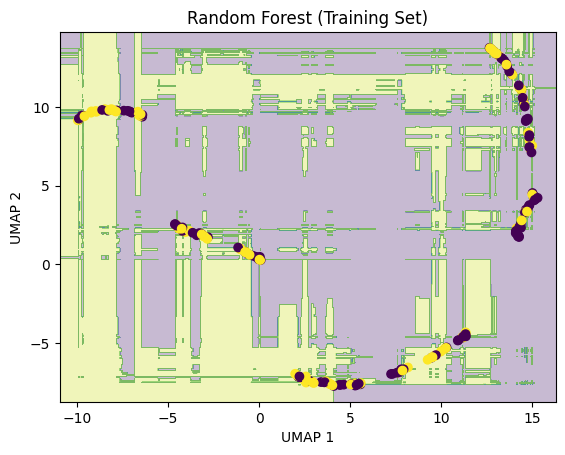

In [45]:
#import numpy as np
#import matplotlib.pyplot as plt

X_set, y_set = X_train_umap, y_train

X1, X2 = np.meshgrid(
    np.arange(X_set[:,0].min()-1, X_set[:,0].max()+1, 0.01),
    np.arange(X_set[:,1].min()-1, X_set[:,1].max()+1, 0.01)
)

plt.contourf(
    X1, X2,
    classifier_umap.predict(
        np.array([X1.ravel(), X2.ravel()]).T
    ).reshape(X1.shape),
    alpha=0.3
)

plt.scatter(X_set[:,0], X_set[:,1], c=y_set)

plt.title("Random Forest (Training Set)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

#Visualise TEST Set

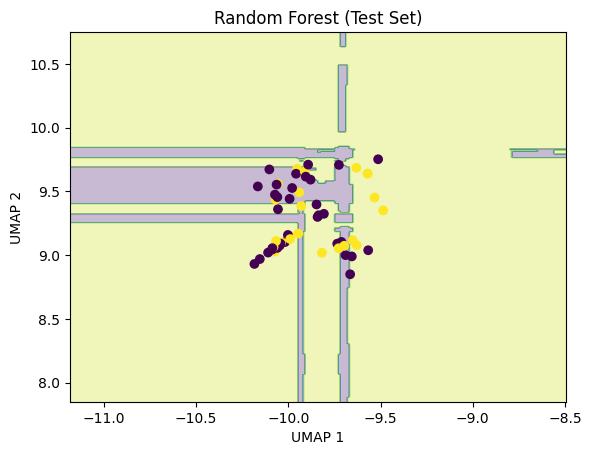

In [46]:
X_set, y_set = X_test_umap, y_test

X1, X2 = np.meshgrid(
    np.arange(X_set[:,0].min()-1, X_set[:,0].max()+1, 0.01),
    np.arange(X_set[:,1].min()-1, X_set[:,1].max()+1, 0.01)
)

plt.contourf(
    X1, X2,
    classifier_umap.predict(
        np.array([X1.ravel(), X2.ravel()]).T
    ).reshape(X1.shape),
    alpha=0.3
)

plt.scatter(X_set[:,0], X_set[:,1], c=y_set)

plt.title("Random Forest (Test Set)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

#for better accuracy remove feature scalling because random forest regression doesnot need it . and also can remove smote . and due to small data set accuracy is low